### Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))  # project root for gates
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '../vis'))  # vis/ for vis_plotting
os.chdir(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))  # data/ paths resolve from project root

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import numpy as np
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

#from vis_plotting.fp_plotting import *
from vis_plotting.general_plotting import *
from vis_plotting.topog_plotting import *
from vis_plotting.met_plotting import *


from gates.data.load_data import LoadBaseSatelliteData


In [2]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

### Data loading

In [3]:
"""
Load the footprints for the region and period with the base data object.
Stores the footprints (without cropping) in data.fp_data_full
load_everything=True also loads the original meteorology, without cropping or interpolating, in data.met_file, as well as the topography and landuse in data.topog_file and data.landcover_file, which are interpolated in space to the shape of the footprints
"""
data = LoadBaseSatelliteData(201401, region="BRAZIL", load_everything=True, verbose=True)
#data = LoadBaseSatelliteData(201603, region="SAHARA", load_everything=True, verbose=True)
data.align_domains(crop_to_intersection=True)
#data.get_country_masks()


---- LOADING FOOTPRINTS
Loading footprint data from data/fp_archive/SOUTHAMERICA/*BRAZIL*_201401*.nc
WITH CHUNKING -
After fp_data_full: 34 tasks
no sampling was done because you didnt pass a valid sampling mode, or freq=1
<xarray.Dataset> Size: 393MB
Dimensions:      (lon: 190, lat: 357, lev: 1, time: 1449, height: 20)
Coordinates:
  * lon          (lon) float32 760B -91.33 -90.98 -90.62 ... -25.5 -25.15 -24.8
  * lat          (lat) float32 1kB -60.98 -60.75 -60.51 ... 21.85 22.09 22.32
  * lev          (lev) |S1 1B b'c'
  * height       (height) float32 80B 500.0 1.5e+03 ... 1.85e+04 1.95e+04
  * time         (time) datetime64[ns] 12kB 2014-01-01T16:04:56 ... 2014-01-3...
Data variables:
    fp           (lat, lon, time) float32 393MB dask.array<chunksize=(357, 190, 290), meta=np.ndarray>
    release_lon  (time) float32 6kB dask.array<chunksize=(1449,), meta=np.ndarray>
    release_lat  (time) float32 6kB dask.array<chunksize=(1449,), meta=np.ndarray>
Attributes:
    max_level:  17
 

## Jeff trying stuff out

### Plot map with bounding box for data

In [ ]:
# Plot all three with distinct styles, zooming to the union of their extents
fig, ax = plot_multiple_data_series(
    data,
    show=("met", "fp", "topo"),
    colours={"met":"tab:blue", "fp":"tab:orange", "topo":"tab:green"},
    linestyles={"met":"-", "fp":"--", "topo":"-."},
    linewidths={"met":2.2, "fp":2.2, "topo":2.2},
    facealpha=0.0,                 # set to, e.g., 0.15 if you want light fills
    projection="PlateCarree",
    wrap_center=0,
    zoom_to_union=False,
    title="UM Domains: Met, Footprints, and Topography"
)
plt.show()

TypeError: object of type 'LoadBaseSatelliteData' has no len()

### Plot topo

### Histogram of topography

# Compare regions

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm


def compare_topography_maps(
    datasets,
    region_names=None,
    n_bins=10,
    vmin=None,
    vmax=None,
    cmap="RdYlGn_r",
    ocean_colour="#1d9cfe",
    land_only=True,
    figure_size=(14, 5.5),
    plot_country_boundaries=True,
    save=False,
    outdir="multi_domain_characterisation",
    filename="topography_maps.png",
):
    """
    Compare topography maps across any number of regions using a shared colour scale.
    """

    n = len(datasets)
    if region_names is None:
        region_names = [f"Region {i+1}" for i in range(n)]
    if len(region_names) != n:
        raise ValueError("region_names must match number of datasets")

    # ---- Build common bins from land-only samples across ALL regions ----
    z_all = [
        get_topography_values(ds, land_only=land_only)
        for ds in datasets
    ]
    bin_edges = common_bin_edges(
        *z_all, n_bins=n_bins, vmin=vmin, vmax=vmax
    )

    lo, hi = bin_edges[0], bin_edges[-1]
    centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    base_cmap = plt.get_cmap(cmap)
    centres01 = (centres - lo) / (hi - lo + 1e-15)
    colours = base_cmap(centres01)

    discrete_cmap = ListedColormap(colours, name=f"{cmap}_{n_bins}bins")
    discrete_cmap.set_bad(ocean_colour)
    norm = BoundaryNorm(bin_edges, ncolors=discrete_cmap.N, clip=True)

    # ---- Figure layout ----
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=figure_size, constrained_layout=True)
    axs = [
        fig.add_subplot(1, n, i + 1, projection=proj)
        for i in range(n)
    ]

    mesh = None

    # ---- Plot each region ----
    for ax, data, title in zip(axs, datasets, region_names):
        ds = data.topog_file
        da = ds["surface_altitude"].where(np.isfinite(ds["surface_altitude"]))

        if land_only:
            lm = get_land_mask(data)
            if lm is not None:
                da = da.where(lm)

        lon = ds["lon"].values
        lat = ds["lat"].values

        ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
        if plot_country_boundaries:
            ax.add_feature(
                cfeature.BORDERS,
                linewidth=0.7,
                edgecolor="black",
                alpha=0.7,
            )
        ax.gridlines(
            draw_labels=False,
            linewidth=0.3,
            color="0.5",
            alpha=0.6,
        )

        mesh = ax.pcolormesh(
            lon,
            lat,
            da.values,
            transform=proj,
            cmap=discrete_cmap,
            norm=norm,
            shading="auto",
        )

        ax.set_title(title)

    # ---- Shared colourbar ----
    cb = fig.colorbar(
        mesh,
        ax=axs,
        orientation="horizontal",
        pad=0.06,
        shrink=0.9,
        boundaries=bin_edges,
        ticks=centres,
    )

    ref = datasets[0].topog_file["surface_altitude"]
    units = ref.attrs.get("units", "m")
    long_name = ref.attrs.get("long_name", "Surface altitude")
    cb.set_label(f"{long_name} [{units}]")

    try:
        cb.ax.set_xticklabels([f"{v:.0f}" for v in centres])
    except Exception:
        pass

    # ---- Save if requested ----
    if save:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        fig.savefig(outdir / filename, dpi=300, bbox_inches="tight")

    plt.show()

    return fig, axs, (discrete_cmap, norm, bin_edges)

In [ ]:
def get_land_mask(data, threshold=0.9):
    """Return a boolean mask (lat, lon) with True for land cells."""
    if hasattr(data, 'landcover_file') and 'land_binary_mask' in data.landcover_file.variables:
        return (data.landcover_file['land_binary_mask'] > threshold)
    # Fallback: anything non-NaN in landcover_fraction implies land; else ~all NaN is ocean.
    if hasattr(data, 'landcover_file') and 'landcover_fraction' in data.landcover_file.variables:
        da = data.landcover_file['landcover_fraction']
        # normalise dims to (lat, lon, pseudo_level)
        if da.dims == ('pseudo_level', 'lat', 'lon'):
            da = da.transpose('lat', 'lon', 'pseudo_level')
        return np.isfinite(da).any(dim='pseudo_level')
    # If we cannot infer, return None
    return None

def get_topography_values(data, land_only=True, land_threshold=0.9):
    """Flattened surface altitude vector (optionally land-only)."""
    da = data.topog_file['surface_altitude'].where(np.isfinite(data.topog_file['surface_altitude']))
    if land_only:
        lm = get_land_mask(data, threshold=land_threshold)
        if lm is not None:
            da = da.where(lm)
    z = da.values.ravel()
    return z[np.isfinite(z)]

import numpy as np

def common_bin_edges(*arrays, n_bins=30, vmin=None, vmax=None):
    """
    Compute common histogram bin edges for any number of arrays.
    """
    if len(arrays) == 0:
        raise ValueError("At least one array is required")

    all_vals = np.concatenate([np.asarray(a) for a in arrays])

    if vmin is None:
        vmin = np.nanmin(all_vals)
    if vmax is None:
        vmax = np.nanmax(all_vals)

    return np.linspace(vmin, vmax, n_bins + 1)

In [ ]:
def compare_topography_histograms(
    datasets,
    region_names=None,
    n_bins=30, vmin=None, vmax=None,
    land_only=True,
    density=False, cumulative=False, log_y=False,
    colours=None,
    figsize=(8, 5),
    save=False,
    outdir="multi_domain_characterisation",
    filename="topography_histograms.png",
):
    """
    Compare topographic height distributions for an arbitrary number of regions.

    Parameters
    ----------
    datasets : sequence
        Sequence of dataset objects (must be compatible with get_topography_values).
    region_names : sequence of str, optional
        Labels for each dataset. Defaults to "Region 1", "Region 2", ...
    colours : sequence of str, optional
        Matplotlib colours (cycled if fewer than datasets).
    """

    if region_names is None:
        region_names = [f"Region {i+1}" for i in range(len(datasets))]

    if colours is None:
        colours = plt.rcParams['axes.prop_cycle'].by_key()['color']

    if len(region_names) != len(datasets):
        raise ValueError("region_names must match number of datasets")

    # Extract topography values for all regions
    z_values = [
        get_topography_values(ds, land_only=land_only)
        for ds in datasets
    ]

    # Compute common bin edges across all regions
    bin_edges = common_bin_edges(
        *z_values, n_bins=n_bins, vmin=vmin, vmax=vmax
    )

    fig, ax = plt.subplots(figsize=figsize)
    colour_cycle = itertools.cycle(colours)

    for z, name, colour in zip(z_values, region_names, colour_cycle):
        ax.hist(
            z,
            bins=bin_edges,
            density=density,
            cumulative=cumulative,
            histtype="step",
            linewidth=1.8,
            color=colour,
            label=name,
        )

    # Axis labels
    y_label = (
        "Density" if density
        else "Cumulative count" if cumulative
        else "Count"
    )

    if log_y:
        ax.set_yscale("log")
        y_label += " (log scale)"

    ref = datasets[0].topog_file["surface_altitude"]
    units = ref.attrs.get("units", "m")
    long_name = ref.attrs.get("long_name", "Surface altitude")

    ax.set_xlabel(f"{long_name} [{units}]")
    ax.set_ylabel(y_label)

    ax.grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.7)
    ax.legend()
    plt.tight_layout()
    plt.show()

    if save:
        from pathlib import Path
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        fig.savefig(outdir / filename, dpi=300, bbox_inches="tight")

    return fig, ax, bin_edges

In [ ]:
from matplotlib.gridspec import GridSpec
from pathlib import Path

def majority_landuse_da(data):
    da = data.landcover_file['landcover_fraction']
    if da.dims == ('pseudo_level', 'lat', 'lon'):
        da = da.transpose('lat', 'lon', 'pseudo_level')
    valid = np.isfinite(da).any(dim='pseudo_level')
    filled = da.fillna(-1e15)
    idx = filled.argmax(dim='pseudo_level')
    pseudo_ids = da['pseudo_level']
    maj = pseudo_ids.isel(pseudo_level=idx).astype(int)
    maj = xr.where(valid, maj, 0).astype(int)
    return maj

def compare_majority_landuse_maps(
    datasets,
    region_names=None,
    figure_size=(14, 5.5),
    plot_country_boundaries=True,
    coastline=True,
    save=False,
    outdir="multi_domain_characterisation",
    filename="majority_landuse_maps.png",
):
    """
    Compare majority land-use maps across any number of regions.
    """

    n = len(datasets)
    if region_names is None:
        region_names = [f"Region {i+1}" for i in range(n)]
    if len(region_names) != n:
        raise ValueError("region_names must match number of datasets")

    # Compute majority land use
    maj_list = [majority_landuse_da(ds) for ds in datasets]

    # Colormap setup (0–9 classes as before)
    ordered_ids = list(range(0, 10))
    colours_list = [CLASS_COLOURS[i] for i in ordered_ids]
    cmap = ListedColormap(colours_list, name="landuse_maj_0to9")
    boundaries = np.arange(-0.5, 10.5, 1.0)
    norm = BoundaryNorm(boundaries, ncolors=cmap.N, clip=False)

    proj = ccrs.PlateCarree()

    # Figure layout: one column per region + legend
    fig = plt.figure(figsize=figure_size, constrained_layout=True)
    gs = GridSpec(1, n + 1, figure=fig, width_ratios=[1] * n + [0.25])

    axes = []
    for i in range(n):
        ax = fig.add_subplot(gs[0, i], projection=proj)
        axes.append(ax)

    ax_leg = fig.add_subplot(gs[0, -1])

    # Plot each region
    for ax, maj, title in zip(axes, maj_list, region_names):
        lon, lat = maj["lon"].values, maj["lat"].values

        if coastline:
            ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
        if plot_country_boundaries:
            ax.add_feature(
                cfeature.BORDERS, linewidth=0.7,
                edgecolor="black", alpha=0.7
            )

        ax.gridlines(draw_labels=False, linewidth=0.3, color="0.5", alpha=0.6)
        ax.pcolormesh(
            lon, lat, maj.values,
            transform=proj, cmap=cmap, norm=norm,
            shading="nearest"
        )
        ax.set_title(title)

    # Build legend showing only classes present in ANY region
    present_ids = np.unique(np.concatenate([
        np.unique(m.values[np.isfinite(m.values)])
        for m in maj_list
    ])).astype(int)
    present_ids = [i for i in present_ids if 0 <= i <= 9]

    handles = [
        Patch(
            facecolor=CLASS_COLOURS[i],
            edgecolor="black",
            label=CLASS_LABELS[i],
        )
        for i in present_ids
    ]

    ax_leg.axis("off")
    leg = ax_leg.legend(
        handles=handles,
        loc="center",
        frameon=True,
        framealpha=0.95,
        title="Majority land‑use",
        fontsize=9,
    )
    try:
        leg._legend_box.align = "left"
    except Exception:
        pass

    # Save if requested
    if save:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        fig.savefig(outdir / filename, dpi=300, bbox_inches="tight")

    plt.show()

    return fig, axes, maj_list, (cmap, norm)

In [ ]:
def landuse_totals(data, area_weighted=False, as_percent=True):
    da = data.landcover_file['landcover_fraction']
    if da.dims == ('pseudo_level', 'lat', 'lon'):
        da = da.transpose('lat', 'lon', 'pseudo_level')
    if area_weighted:
        lat = da['lat'].values
        cosw = np.cos(np.deg2rad(lat))
        weights2d = xr.DataArray(
            np.repeat(cosw[:, None], da.sizes['lon'], axis=1),
            coords={'lat': da['lat'], 'lon': da['lon']},
            dims=('lat', 'lon')
        )
        daw = da * weights2d.broadcast_like(da)
        summed = daw.sum(dim=('lat', 'lon'), skipna=True)
    else:
        summed = da.sum(dim=('lat', 'lon'), skipna=True)
    class_ids = [int(c) for c in da['pseudo_level'].values.tolist()]
    totals = np.array(summed.values, dtype=float)
    freq = {cid: totals[i] for i, cid in enumerate(class_ids) if np.isfinite(totals[i])}
    if as_percent:
        s = np.sum(list(freq.values()))
        if s > 0:
            freq = {k: v/s*100.0 for k, v in freq.items()}
    return freq

def compare_landuse_frequency(
    datasets,
    region_names=None,
    area_weighted=True,
    as_percent=True,
    figsize=(10, 4.8),
    hatches=None,
    save=False,
    outdir="multi_domain_characterisation",
    filename="landuse_frequency.png",
):
    """
    Compare land-use class frequencies across any number of regions.
    """

    n = len(datasets)
    if region_names is None:
        region_names = [f"Region {i+1}" for i in range(n)]
    if len(region_names) != n:
        raise ValueError("region_names must match number of datasets")

    if hatches is None:
        hatches = [""] * n
    if len(hatches) < n:
        hatches = (hatches * n)[:n]

    # Compute land-use frequencies for each region
    freqs = [
        landuse_totals(ds, area_weighted=area_weighted, as_percent=as_percent)
        for ds in datasets
    ]

    # Union of all classes present
    plot_ids = sorted(set().union(*[f.keys() for f in freqs]))

    labels = [CLASS_LABELS.get(cid, f"class {cid}") for cid in plot_ids]
    colours = [CLASS_COLOURS.get(cid, "steelblue") for cid in plot_ids]

    # Bar positions
    x = np.arange(len(plot_ids))
    width = 0.8 / n

    fig, ax = plt.subplots(figsize=figsize)

    # Plot each region
    for i, (freq, name, hatch) in enumerate(zip(freqs, region_names, hatches)):
        vals = [freq.get(cid, 0.0) for cid in plot_ids]
        ax.bar(
            x - 0.4 + width/2 + i*width,
            vals,
            width=width,
            color=colours,
            edgecolor="black",
            hatch=hatch,
            label=name,
        )

    # Labels and formatting
    y_label = "Share of fractional landcover (%)" if as_percent else "Total fractional landcover"
    if area_weighted:
        y_label += " (area‑weighted)"

    ax.set_ylabel(y_label)
    ax.set_title("Land‑use frequency by class")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.grid(True, axis="y", linestyle=":", linewidth=0.6, alpha=0.7)
    ax.legend()

    plt.tight_layout()

    # Save if requested
    if save:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        fig.savefig(outdir / filename, dpi=300, bbox_inches="tight")

    plt.show()

    return fig, ax, freqs

In [ ]:
data_x = LoadBaseSatelliteData(201403, region="SAHARA", load_everything=True, verbose=False)
data_x.align_domains()

# Plot all three series' with distinct styles

fig, ax = plot_multiple_data_series(
    data_x,
    show=("met", "fp", "topo"),
    colours={"met":"tab:blue", "fp":"tab:orange", "topo":"tab:green"},
    linestyles={"met":"-", "fp":"--", "topo":"-."},
    linewidths={"met":2.2, "fp":2.2, "topo":2.2},
    facealpha=0.0,                 # set to, e.g., 0.15 if you want light fills
    projection="PlateCarree",
    wrap_center=0,
    zoom_to_union=False,
    title="UM Domains: Met, Footprints, and Topography"
)
plt.show()

# Run

In [ ]:
data_A = LoadBaseSatelliteData(201401, region="BRAZIL", load_everything=True, verbose=False)
data_B = LoadBaseSatelliteData(201401, region="CHINA", load_everything=True, verbose=False)
data_C = LoadBaseSatelliteData(201401, region="INDIA", load_everything=True, verbose=False)
data_D = LoadBaseSatelliteData(201401, region="SAHARA", load_everything=True, verbose=False)

region_names = ["Brazil", "China", "India", "Sahara"]

data_A.align_domains(crop_to_intersection=True)
data_B.align_domains(crop_to_intersection=True)
data_C.align_domains(crop_to_intersection=True)
data_D.align_domains(crop_to_intersection=True)



In [ ]:
compare_topography_histograms(datasets=[data_A, data_B, data_C, data_D],
                            region_names=region_names,    density=True,    log_y=True, n_bins=50,
                            save = True,
                            filename="topography_histograms_not_log.png",

                            )

In [ ]:
compare_majority_landuse_maps(
    datasets=[data_A, data_B, data_C, data_D],
    region_names=region_names,
    filename="majority_landuse_4domains.png",
    save=True,
)

In [ ]:
compare_landuse_frequency(
    datasets=[data_A, data_B, data_C, data_D],
    region_names=   region_names,
    hatches=["", "//", "xx"],
    filename="landuse_frequency_4domains.png",
    save=True,
)

In [ ]:
plot_multiple_data_series(
    datasets=[data_A, data_B, data_C, data_D],
    region_names=region_names,
    show=("met",),
    filename="bounds_4_regions_map.png",
    title="",
    save=True,
    zoom_to_union=False,
)

---- Not yet added ---

In [ ]:
compare_topography_maps(
    datasets=[data_A, data_B, data_C, data_D],
    region_names=region_names,
    n_bins=12,
    filename="topography_4domains.png",
    save=True,
)

In [17]:
level_ds = data.met_file.resample(time='6h').nearest().sel(levels=1, lat=data.met_file.lat.values[::5], lon=data.met_file.lon.values[::5])[["x_wind", "y_wind"]]

level_ds.chunk({'time': -1, 'lat': -1, 'lon': -1}).load()
level_ds

<xarray.Dataset> Size: 3MB
Dimensions:       (lat: 72, lon: 38, time: 124)
Coordinates:
    levels        int32 4B 1
  * time          (time) datetime64[ns] 992B 2014-01-01 ... 2014-01-31T18:00:00
  * lat           (lat) float32 288B -60.98 -59.81 -58.64 ... 19.75 20.92 22.09
  * lon           (lon) float32 152B -91.33 -89.57 -87.81 ... -27.97 -26.21
    sigma         float32 4B 0.9977
    level_height  float32 4B 20.0
Data variables:
    x_wind        (lat, lon, time) float32 1MB dask.array<chunksize=(72, 38, 8), meta=np.ndarray>
    y_wind        (lat, lon, time) float32 1MB dask.array<chunksize=(72, 38, 8), meta=np.ndarray>
Attributes:
    source:           Data from Met Office Unified Model
    author:           Elena Fillola (ef17148)
    created:          2022-11-11 17:11
    transformations:  interpolated linearly in space to NAME resolution, inte...

<WindroseAxes: title={'center': 'Annual\n Lev1'}>

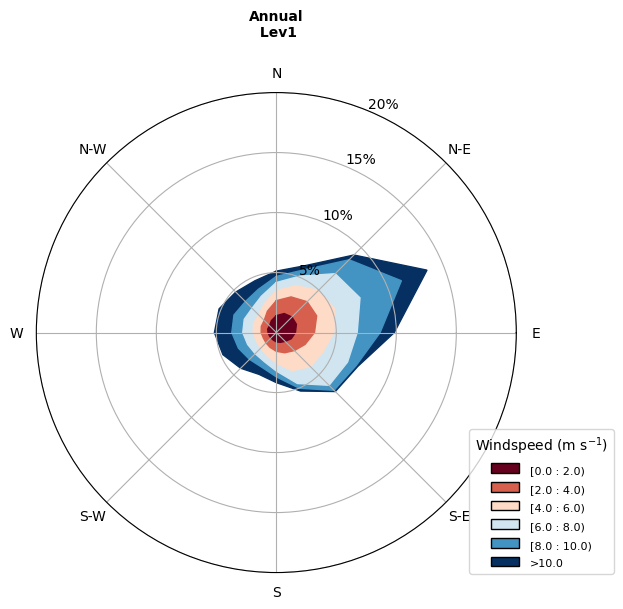

In [18]:
plot_single_windrose(level_ds,  legend=True, title=f"Annual\n Lev1")

In [19]:
data.plot_footprint_mean(data_1.met_file.time, data_1.fp_data_full.time)

AttributeError: 'LoadBaseSatelliteData' object has no attribute 'plot_footprint_mean'

2026.3.0
---- LOADING FOOTPRINTS
Loading footprint data from data/fp_archive/SOUTHAMERICA/*BRAZIL*_2014*.nc
WITH CHUNKING -
After fp_data_full: 1058 tasks
reduced the number of datapoints by frequency 50
<xarray.Dataset> Size: 90MB
Dimensions:      (lat: 357, lon: 190, time: 331, lev: 1, height: 20)
Coordinates:
  * lon          (lon) float32 760B -91.33 -90.98 -90.62 ... -25.5 -25.15 -24.8
  * lat          (lat) float32 1kB -60.98 -60.75 -60.51 ... 21.85 22.09 22.32
  * lev          (lev) |S1 1B b'c'
  * height       (height) float32 80B 500.0 1.5e+03 ... 1.85e+04 1.95e+04
  * time         (time) datetime64[ns] 3kB 2014-01-01T16:04:56 ... 2014-12-14...
Data variables:
    fp           (lat, lon, time) float32 90MB dask.array<chunksize=(357, 190, 331), meta=np.ndarray>
    release_lon  (time) float32 1kB dask.array<chunksize=(331,), meta=np.ndarray>
    release_lat  (time) float32 1kB dask.array<chunksize=(331,), meta=np.ndarray>
Attributes:
    max_level:  17
    author:     rt17603
 

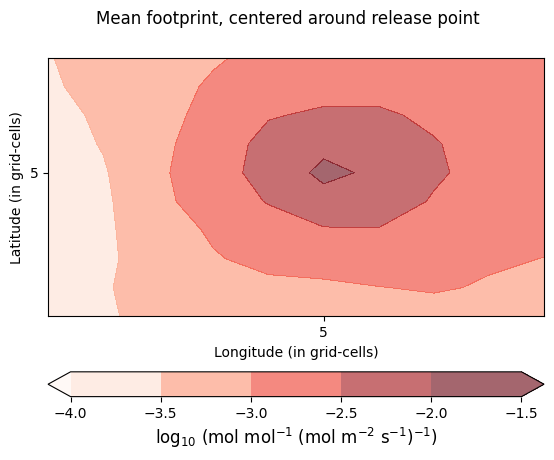

In [37]:
from gates.data.load_data import LoadSquareSatelliteData
data_brazil = LoadSquareSatelliteData(2014, region="BRAZIL", load_everything=True, verbose=True, freq=50)
data_brazil.align_domains(crop_to_intersection=True)
data_brazil.plot_footprint_mean(add_cbar=True)

2026.3.0
---- LOADING FOOTPRINTS
Loading footprint data from data/fp_archive/NORTHAFRICA/*NORTHAFRICA*_2014*.nc
WITH CHUNKING -
After fp_data_full: 832 tasks
reduced the number of datapoints by frequency 50
<xarray.Dataset> Size: 86MB
Dimensions:      (lat: 240, lon: 391, time: 230, lev: 1, height: 20)
Coordinates:
  * lon          (lon) float32 2kB -50.0 -49.65 -49.3 ... 86.58 86.93 87.28
  * lat          (lat) float32 960B -15.0 -14.77 -14.53 ... 40.46 40.69 40.93
  * lev          (lev) |S1 1B b'c'
  * height       (height) float32 80B 500.0 1.5e+03 ... 1.85e+04 1.95e+04
  * time         (time) datetime64[ns] 2kB 2014-01-01T11:01:16 ... 2014-12-14...
Data variables:
    fp           (lat, lon, time) float32 86MB dask.array<chunksize=(240, 391, 230), meta=np.ndarray>
    release_lon  (time) float32 920B dask.array<chunksize=(230,), meta=np.ndarray>
    release_lat  (time) float32 920B dask.array<chunksize=(230,), meta=np.ndarray>
Attributes:
    max_level:  17
    author:     lw13938


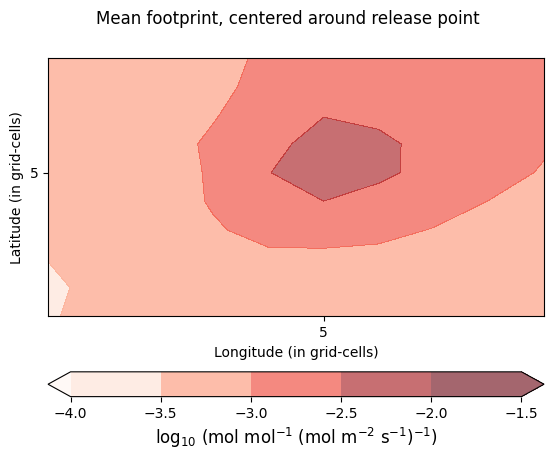

In [38]:
data_sahara = LoadSquareSatelliteData(2014, region="SAHARA", load_everything=True, verbose=True, freq=50)
data_sahara.align_domains(crop_to_intersection=True)
data_sahara.plot_footprint_mean(add_cbar=True)

2026.3.0
---- LOADING FOOTPRINTS
Loading footprint data from data/fp_archive/INDIA/*SOUTHASIA*_2014*.nc
WITH CHUNKING -
After fp_data_full: 558 tasks
reduced the number of datapoints by frequency 25
<xarray.Dataset> Size: 24MB
Dimensions:      (lat: 180, lon: 155, time: 213, lev: 1, height: 20)
Coordinates:
  * lon          (lon) float32 620B 55.0 55.35 55.7 56.06 ... 108.5 108.9 109.2
  * lat          (lat) float32 720B 6.0 6.234 6.468 6.702 ... 47.42 47.65 47.89
  * lev          (lev) object 8B 'column'
  * height       (height) float32 80B 500.0 1.5e+03 ... 1.85e+04 1.95e+04
  * time         (time) datetime64[ns] 2kB 2014-01-01T07:44:36 ... 2014-12-13...
Data variables:
    fp           (lat, lon, time) float32 24MB dask.array<chunksize=(180, 155, 213), meta=np.ndarray>
    release_lon  (time) float32 852B dask.array<chunksize=(213,), meta=np.ndarray>
    release_lat  (time) float32 852B dask.array<chunksize=(213,), meta=np.ndarray>
Attributes:
    max_level:  15
    author:     ag1

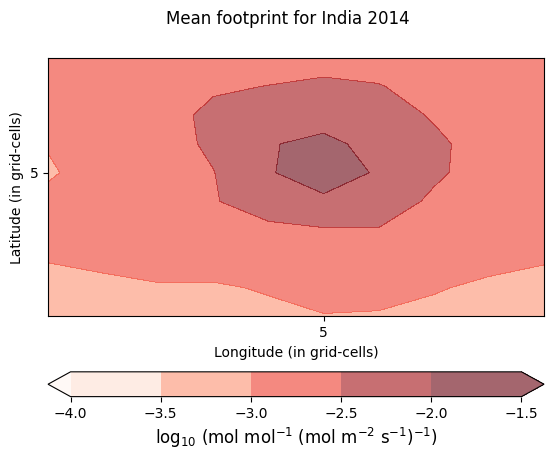

In [39]:
data_india = LoadSquareSatelliteData(2014, region="INDIA", load_everything=True, verbose=True, freq=25)
data_india.align_domains(crop_to_intersection=True)
data_india.plot_footprint_mean(add_cbar=True, title="Mean footprint for India 2014")

2026.3.0
---- LOADING FOOTPRINTS
Loading footprint data from data/fp_archive/CHINA/*EASTASIA*_2014*.nc
WITH CHUNKING -


After fp_data_full: 1084 tasks
reduced the number of datapoints by frequency 50
<xarray.Dataset> Size: 117MB
Dimensions:      (lat: 340, lon: 391, time: 220, lev: 1, height: 20)
Coordinates:
  * lon          (lon) float32 2kB 54.52 54.87 55.22 55.57 ... 191.1 191.4 191.8
  * lat          (lat) float32 1kB -5.183 -4.949 -4.715 ... 73.68 73.91 74.14
  * lev          (lev) |S1 1B b'c'
  * height       (height) float32 80B 500.0 1.5e+03 ... 1.85e+04 1.95e+04
  * time         (time) datetime64[ns] 2kB 2014-01-01T04:27:32 ... 2014-12-13...
Data variables:
    fp           (lat, lon, time) float32 117MB dask.array<chunksize=(340, 391, 186), meta=np.ndarray>
    release_lon  (time) float32 880B dask.array<chunksize=(220,), meta=np.ndarray>
    release_lat  (time) float32 880B dask.array<chunksize=(220,), meta=np.ndarray>
Attributes:
    max_level:  17
    author:     jsheng1
    created:    2019-06-19 03:57:53.028904
Loading 220 footprints
loaded fp variable
----- Cutting footprints to square 

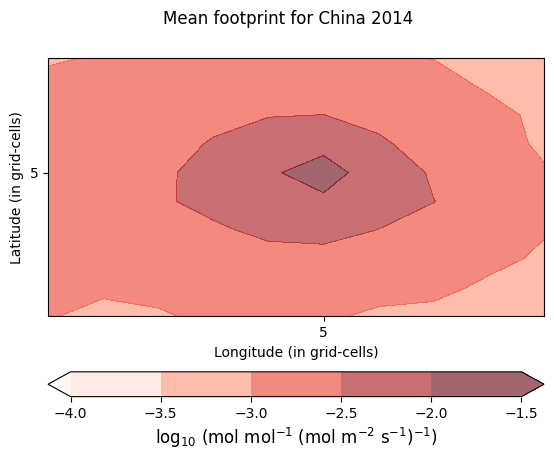

In [40]:
data_china = LoadSquareSatelliteData(2014, region="CHINA", load_everything=True, verbose=True, freq=50)
data_china.align_domains(crop_to_intersection=True)
data_china.plot_footprint_mean(add_cbar=True, title="Mean footprint for China 2014")

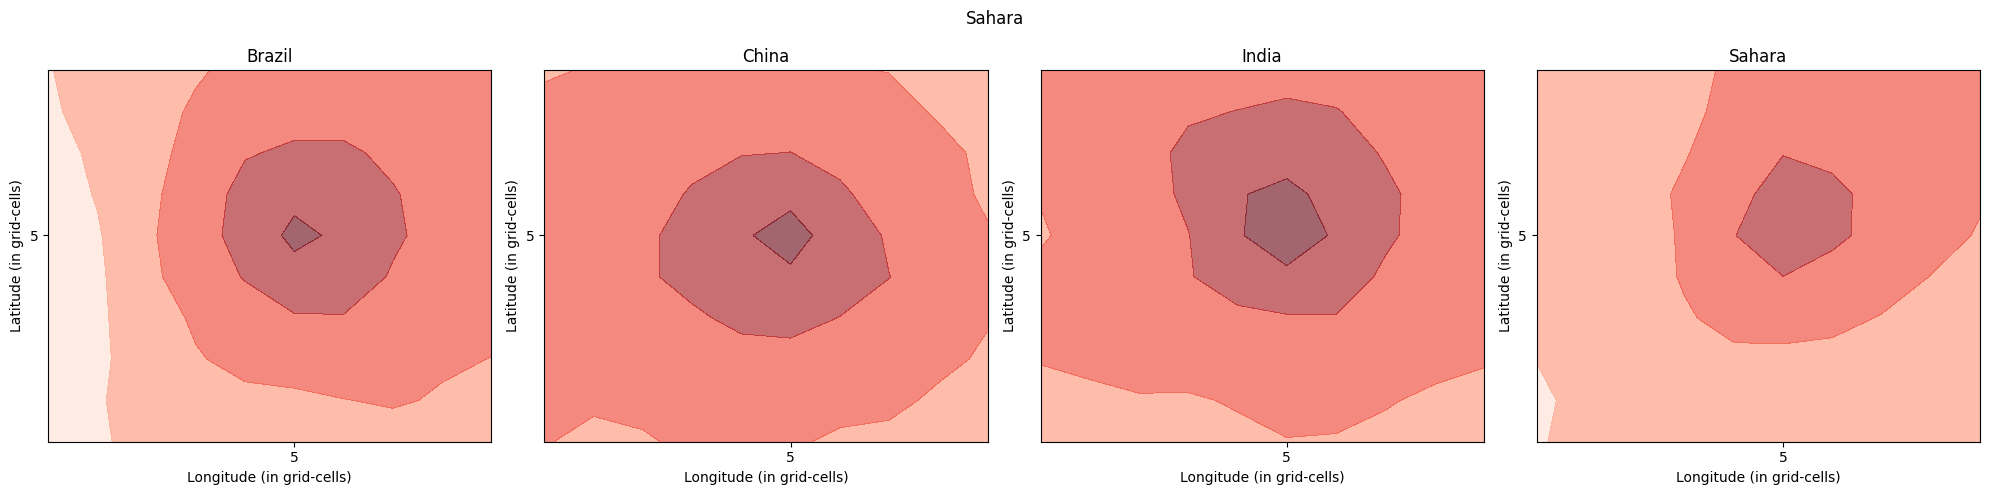

In [41]:
import matplotlib.pyplot as plt
import numpy as np

datasets   = [data_brazil, data_china, data_india, data_sahara]
names      = ["Brazil", "China", "India", "Sahara"]

fig, axs = plt.subplots(1, len(datasets), figsize=(5*len(datasets), 5))

_original_subplots = plt.subplots
_original_show = plt.show

for data, ax, name in zip(datasets, axs.flat, names):
    # redirect plt.subplots → return our target ax, plt.show → no-op
    plt.subplots = lambda *a, **kw: (fig, ax)
    plt.show = lambda *a, **kw: None
    data.plot_footprint_mean(title=name)
    ax.set_title(name)          # set title per subplot


plt.subplots = _original_subplots
plt.show     = _original_show
plt.tight_layout()
plt.show()

/tmp/ipykernel_1660617/3577793269.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


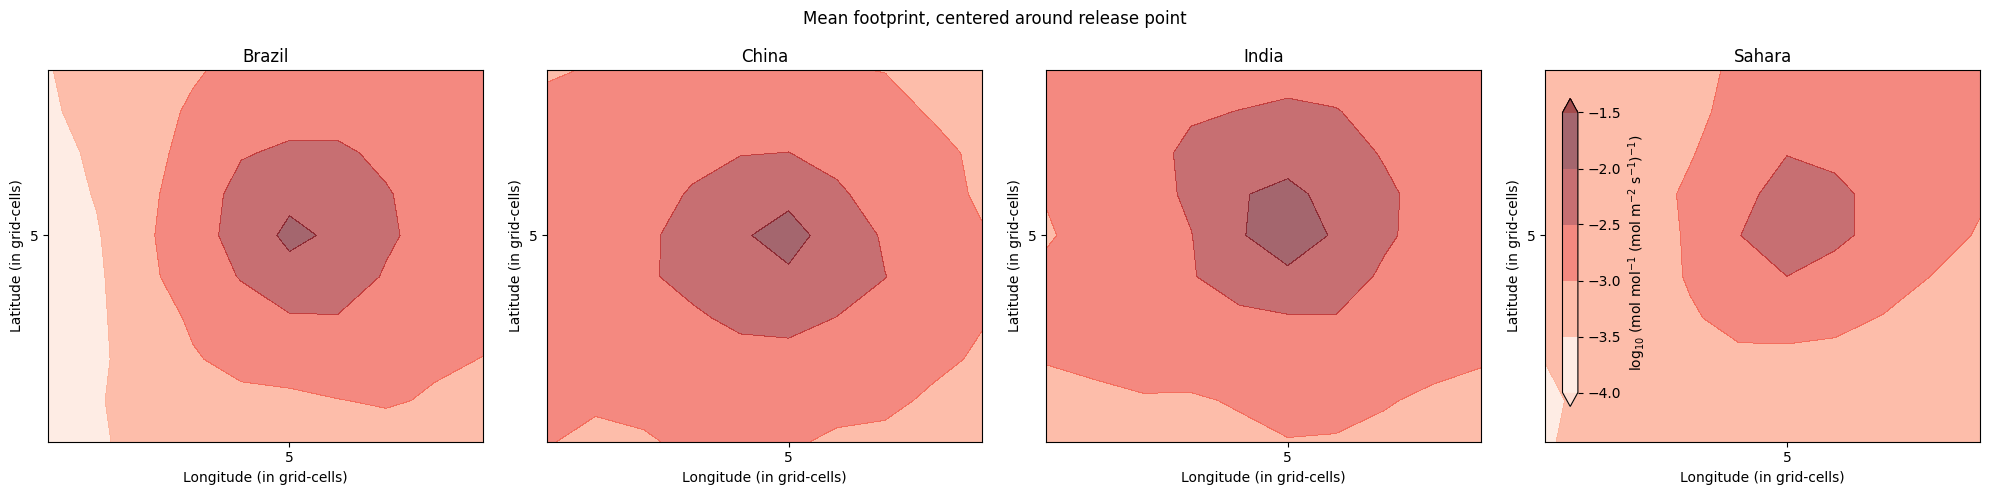

In [42]:
import matplotlib.pyplot as plt
import numpy as np

datasets = [data_brazil, data_china, data_india, data_sahara]
names    = ["Brazil", "China", "India", "Sahara"]

fig, axs = plt.subplots(1, len(datasets), figsize=(5*len(datasets), 5))

_original_subplots = plt.subplots
_original_show = plt.show
last_cf = [None]

for data, ax, name in zip(datasets, axs.flat, names):
    # capture the contourf return value for the colorbar
    _orig_contourf = ax.contourf
    def capturing_contourf(*a, _ax=ax, _orig=_orig_contourf, **kw):
        result = _orig(*a, **kw)
        last_cf[0] = result
        return result
    ax.contourf = capturing_contourf

    plt.subplots = lambda *a, **kw: (fig, ax)
    plt.show = lambda *a, **kw: None
    data.plot_footprint_mean()
    ax.set_title(name)
    ax.contourf = _orig_contourf  # restore

plt.subplots = _original_subplots
plt.show     = _original_show

cbar = fig.colorbar(last_cf[0], ax=axs.tolist(), orientation='vertical', pad=0.02, shrink=0.8)
cbar.set_label(r'log$_{10}$ (mol mol$^{-1}$ (mol m$^{-2}$ s$^{-1}$)$^{-1}$)', size=10)

plt.tight_layout()
plt.show()